# Anomaly detection 2/3 — Gaussian Mixture Models

TinyML course, Module 8. Adapted from the original course notebook (`Anomaly GMM.ipynb`), which follows Géron, *Hands-On ML*, ch. 9.

K-means scored by *distance* and drew spherical boundaries. A **GMM** models normal data as a mixture of K Gaussians — each with a mean **and a covariance matrix** — so clusters can be elongated and correlated. The anomaly score becomes a **log-likelihood**: samples in low-density regions are anomalies.

Plan:
1. Fix the elliptic case that broke K-means
2. `covariance_type` — the flexibility/parameter knob
3. Likelihood thresholding on **your fan features** and a head-to-head with K-means

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture

# The elliptic data that defeated K-means in notebook 1
X1, _ = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, _ = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]

gm = GaussianMixture(n_components=3, n_init=10, random_state=42).fit(X)
print('converged:', gm.converged_)
print('weights:', gm.weights_.round(3))

converged: True
weights: [0.4  0.21 0.39]


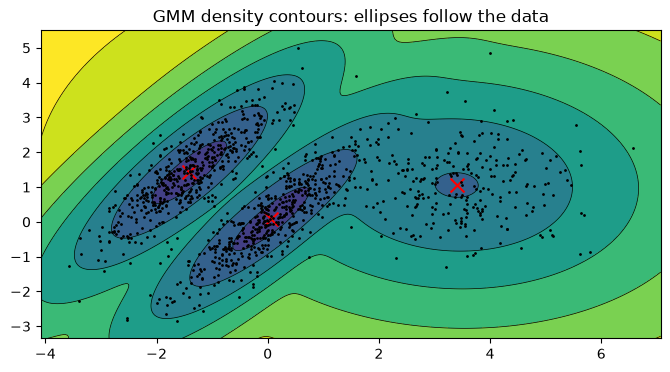

In [2]:
def plot_gmm(gm, X, title=''):
    mins, maxs = X.min(0) - 0.5, X.max(0) + 0.5
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], 300),
                         np.linspace(mins[1], maxs[1], 300))
    Z = -gm.score_samples(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, norm=LogNorm(vmin=1.0, vmax=30.0), levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z, norm=LogNorm(vmin=1.0, vmax=30.0), levels=np.logspace(0, 2, 12),
                linewidths=0.5, colors='k')
    plt.plot(X[:, 0], X[:, 1], 'k.', ms=2)
    plt.scatter(*gm.means_.T, marker='x', s=100, c='r')
    plt.title(title)

plt.figure(figsize=(8, 4))
plot_gmm(gm, X, 'GMM density contours: ellipses follow the data')
plt.show()

## `covariance_type` — how much shape freedom?

- `"spherical"` — circles of different radius (≈ K-means with soft assignments)
- `"diag"` — axis-aligned ellipses (covariance matrices are diagonal)
- `"tied"` — one shared full covariance for all clusters
- `"full"` (default) — every cluster its own full covariance

More freedom = more parameters = more data needed to fit them. On 13 fan features, a *full* covariance per component is 13×13 — with few clusters and enough windows that's fine; with many features consider `diag`.

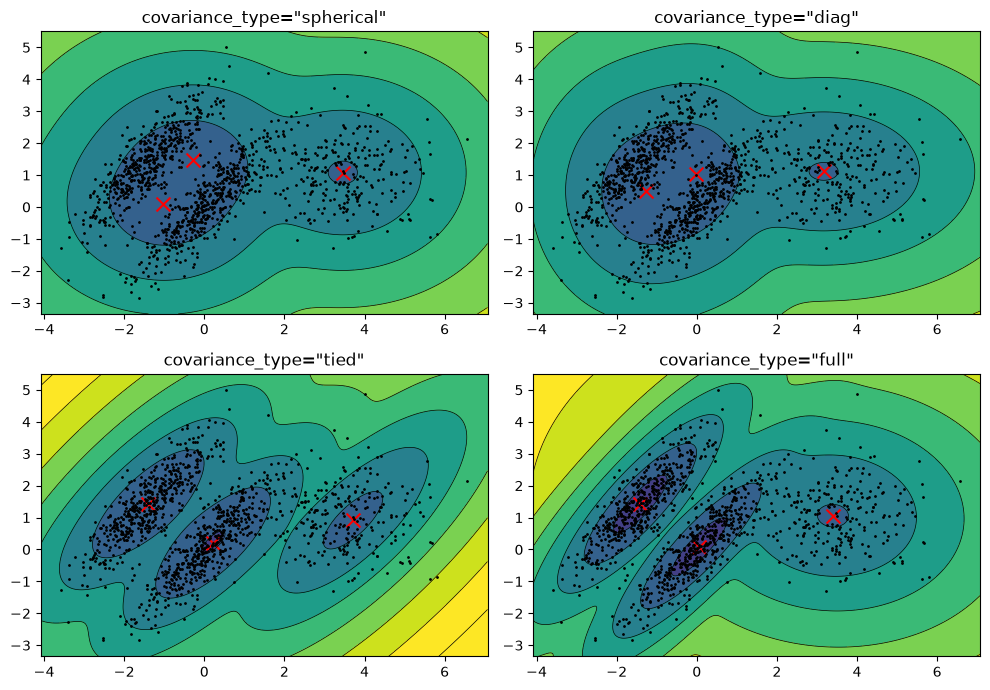

In [3]:
fig = plt.figure(figsize=(10, 7))
for i, ct in enumerate(['spherical', 'diag', 'tied', 'full']):
    gm_v = GaussianMixture(n_components=3, n_init=5, covariance_type=ct,
                           random_state=42).fit(X)
    plt.subplot(2, 2, i + 1)
    plot_gmm(gm_v, X, f'covariance_type="{ct}"')
plt.tight_layout(); plt.show()

## Anomaly detection = density thresholding

`gm.score_samples(X)` returns the log-likelihood of each sample. Pick a threshold such that a chosen fraction of training data falls below it — e.g. if you expect ~2 % outliers, use the 2nd percentile.

density threshold: -5.94


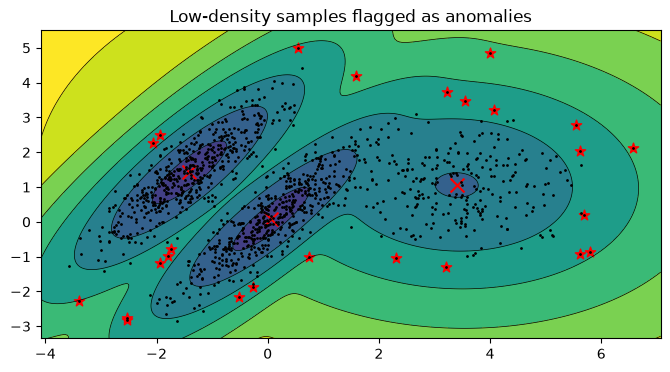

In [4]:
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 2)
anomalies = X[densities < density_threshold]
print(f'density threshold: {density_threshold:.2f}')

plt.figure(figsize=(8, 4))
plot_gmm(gm, X, 'Low-density samples flagged as anomalies')
plt.scatter(anomalies[:, 0], anomalies[:, 1], color='r', marker='*', s=60)
plt.show()

## Part 2 — Your fan features

Same protocol as notebook 1 (so the numbers are directly comparable):

- **fit** the mixture on half the `normal` windows
- **calibrate** the threshold on a *different* slice of normal windows — the 2nd percentile of their log-likelihood
- **report** on everything else: the remaining normal windows (false alarms) and every fault window, held-out class included

The calibrate step is not bureaucracy. A GMM with full covariances has hundreds of free parameters; fitted to a few dozen windows it can put a sharp peak on each one, so the likelihoods it assigns to its own training data say nothing about unseen healthy data. Read the threshold off the fit set instead and this detector promises 2 % false alarms and delivers 41 %.

Note the sign flip vs K-means: **low** likelihood = anomaly.

In [ ]:
import os, sys
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sys.path.insert(0, os.path.abspath('../../module7-models/rf-features'))
from train_rf import load_windows, FEATURE_NAMES   # noqa: E402

DATA_DIR = '../../module7-models/rf-features/data/raw'
HELD_OUT = 'scrape'   # keep identical to notebook 1

X_raw, X_feat, y, groups, _ = load_windows(DATA_DIR)

# Same three-way split as notebook 1, so the numbers are directly comparable.
idx_normal = np.where(y == 'normal')[0]
rng = np.random.default_rng(0)
rng.shuffle(idx_normal)
n_norm = len(idx_normal)
fit_idx = idx_normal[:int(0.5 * n_norm)]
cal_idx = idx_normal[int(0.5 * n_norm):int(0.7 * n_norm)]
test_idx = idx_normal[int(0.7 * n_norm):]
fault_idx = np.where(y != 'normal')[0]

scaler = StandardScaler().fit(X_feat[fit_idx])
Z = scaler.transform(X_feat)


def n_free_params(K, d, cov):
    """Free parameters in a K-component GMM on d features: means + covariances + weights."""
    shape = {'spherical': 1, 'diag': d, 'full': d * (d + 1) // 2}[cov]
    return K * d + K * shape + (K - 1)


# covariance_type='diag', NOT the sklearn default 'full' -- see the table below.
gm_fan = GaussianMixture(n_components=3, n_init=10, covariance_type='diag',
                         random_state=0).fit(Z[fit_idx])
loglik = gm_fan.score_samples(Z)
thr_gmm = np.percentile(loglik[cal_idx], 2)
print(f'GMM log-likelihood threshold: {thr_gmm:.2f}  '
      f'({n_free_params(3, Z.shape[1], "diag")} parameters fitted to {len(fit_idx)} windows)')

# The two shortcuts, priced. Rows = how much shape freedom, columns = where the
# threshold came from. FA is measured on held-out normal windows either way.
print(f"\n{'covariance':>10s} {'params':>7s} | {'threshold from FIT set':>22s} | "
      f"{'from held-out set':>22s}")
for cov in ('diag', 'full'):
    g = GaussianMixture(n_components=3, n_init=10, covariance_type=cov,
                        random_state=0).fit(Z[fit_idx])
    ll = g.score_samples(Z)
    cols = []
    for src in (fit_idx, cal_idx):
        t = np.percentile(ll[src], 2)
        cols.append(f'{np.mean(ll[test_idx] < t):5.1%} FA {np.mean(ll[fault_idx] < t):6.1%} caught')
    print(f'{cov:>10s} {n_free_params(3, Z.shape[1], cov):7d} | {cols[0]:>22s} | {cols[1]:>22s}')

In [ ]:
# Head-to-head: GMM likelihood vs K-means distance, identical splits, and both
# thresholds calibrated on the same held-out normal windows.
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Z[fit_idx])
d = np.linalg.norm(Z[:, None, :] - km.cluster_centers_[None, :, :], axis=2).min(axis=1)
thr_km = np.percentile(d[cal_idx], 98)

report_idx = np.concatenate([test_idx, fault_idx])   # unseen by model AND threshold
df = pd.DataFrame({
    'state': y[report_idx],
    'gmm_anom': loglik[report_idx] < thr_gmm,
    'km_anom': d[report_idx] > thr_km,
})
summary = df.groupby('state').mean(numeric_only=True)
summary.columns = ['GMM flags', 'K-means flags']
print('Fraction of windows flagged per state (held-out =', HELD_OUT, '):')
print(summary.round(3))
summary.plot.bar(figsize=(8, 4), title='Detection rate per fan state')
plt.axhline(0.02, color='gray', ls=':', label='design false-alarm rate')
plt.legend(); plt.tight_layout(); plt.show()

## Part 3 — Where the covariance actually pays

Look at the table above: on all 13 features **both detectors are perfect**. Their scores separate normal from fault with ROC AUC 1.0000 — the fan faults are simply far away in 13-dimensional space, and no amount of shape modelling can improve on "already perfect". That is worth knowing on its own: *when the easy method already works, the sophisticated one buys you nothing but flash and cycles* — and K-means is the one Edge Impulse gives you as an on-device block.

So where does the covariance earn its keep? Where the geometry is tight. Drop to **two** features and the picture from Part 1 reappears on real fan data.

In [ ]:
# Two features only: RMS on x and y. Fit, calibrate and report exactly as above.
cols = [FEATURE_NAMES.index('rms_x'), FEATURE_NAMES.index('rms_y')]
scaler2 = StandardScaler().fit(X_feat[fit_idx][:, cols])
Z2 = scaler2.transform(X_feat[:, cols])

gm2 = GaussianMixture(3, covariance_type='full', n_init=10, random_state=0).fit(Z2[fit_idx])
km2 = KMeans(3, n_init=10, random_state=0).fit(Z2[fit_idx])
score_gmm = -gm2.score_samples(Z2)                                    # bigger = more anomalous
score_km = np.linalg.norm(Z2[:, None, :] - km2.cluster_centers_[None], axis=2).min(axis=1)

# Frame the plot on the healthy cloud: the 'off' windows sit hundreds of sigma
# away (a stopped fan has almost no vibration) and would squash everything.
lo, hi = Z2[idx_normal].min(0) - 2.5, Z2[idx_normal].max(0) + 2.5
gx, gy = np.meshgrid(np.linspace(lo[0], hi[0], 400), np.linspace(lo[1], hi[1], 400))
grid = np.c_[gx.ravel(), gy.ravel()]
vis = np.all((Z2 > lo) & (Z2 < hi), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
panels = [('GMM  (log-likelihood)', score_gmm, -gm2.score_samples(grid)),
          ('K-means  (distance)', score_km,
           np.linalg.norm(grid[:, None, :] - km2.cluster_centers_[None], axis=2).min(axis=1))]
for ax, (name, score, gscore) in zip(axes, panels):
    thr = np.percentile(score[cal_idx], 98)
    ax.contourf(gx, gy, (gscore > thr).reshape(gx.shape), levels=[-.5, .5, 1.5],
                colors=['#e8f5e9', '#ffebee'])
    ax.contour(gx, gy, gscore.reshape(gx.shape), levels=[thr], colors='k', linewidths=1.5)
    ax.plot(Z2[fit_idx, 0], Z2[fit_idx, 1], 'o', ms=5, c='#1b5e20', label='normal (fit)')
    ax.plot(Z2[test_idx, 0], Z2[test_idx, 1], 'o', ms=6, mfc='none', mew=1.3,
            c='#1b5e20', label='normal (held out)')
    f_vis = fault_idx[vis[fault_idx]]
    ax.plot(Z2[f_vis, 0], Z2[f_vis, 1], 'x', ms=5, mew=1.2, c='#c62828', label='fault')
    ax.set_title(f'{name}\nfalse alarms {np.mean(score[test_idx] > thr):.1%}    '
                 f'faults caught {np.mean(score[fault_idx] > thr):.1%}', fontsize=10)
    ax.set_xlabel('rms_x (standardised)'); ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1])
axes[0].set_ylabel('rms_y (standardised)'); axes[0].legend(fontsize=8, loc='lower left')
fig.suptitle('Healthy vibration forms narrow, tilted clusters. K-means has to inflate a\n'
             'sphere to cover each one — and swallows the faults sitting right beside it.',
             fontsize=11)
fig.tight_layout(); plt.show()

# Is that one lucky split? Re-draw the fit/calibrate/test partition 8 times.
rows = []
for seed in range(8):
    r = np.random.default_rng(seed); shuf = idx_normal.copy(); r.shuffle(shuf)
    f_i, c_i, t_i = (shuf[:int(.5 * n_norm)], shuf[int(.5 * n_norm):int(.7 * n_norm)],
                     shuf[int(.7 * n_norm):])
    Zs = StandardScaler().fit(X_feat[f_i][:, cols]).transform(X_feat[:, cols])
    g = GaussianMixture(3, covariance_type='full', n_init=10, random_state=0).fit(Zs[f_i])
    k = KMeans(3, n_init=10, random_state=0).fit(Zs[f_i])
    row = []
    for s in (-g.score_samples(Zs),
              np.linalg.norm(Zs[:, None, :] - k.cluster_centers_[None], axis=2).min(axis=1)):
        t = np.percentile(s[c_i], 98)
        row += [np.mean(s[t_i] > t), np.mean(s[fault_idx] > t)]
    rows.append(row)
m = np.array(rows).mean(axis=0)
print(f'Averaged over 8 random splits:')
print(f'  GMM      false alarms {m[0]:5.1%}   faults caught {m[1]:5.1%}')
print(f'  K-means  false alarms {m[2]:5.1%}   faults caught {m[3]:5.1%}')
print(f'  -> shape modelling buys {m[1] - m[3]:+.1%} detection at a comparable false-alarm rate')

**Discussion**

1. Where do GMM and K-means disagree? Plot the two scores against each other (scatter, coloured by state) to see *which* windows they disagree on.
2. The 13-feature cell defaults to `covariance_type='diag'`. Switch it to `'full'` and watch both columns of the table move: 314 free parameters fitted to 47 windows. Roughly how many training windows would `full` need before it starts to pay?
3. In Part 3, change `cols` to another pair — `std_x`/`std_y`, or `kurt_x`/`kurt_z`. Which pairs make the covariance matter, and what do those pairs have in common physically?
4. On-device: a fitted GMM is just K means + K covariance matrices — **emlearn can convert `GaussianMixture` to C** (`emlearn.convert(gm)`), the same workflow as your Random Forest. Sketch what the firmware changes would be relative to Exercise 7.1. <!-- VERIFY: emlearn GMM/EllipticEnvelope support — listed under supported models in the emlearn docs -->

**Limitations:** both methods score *feature vectors*. If a fault only shows up in the *shape* of the waveform rather than in these 13 numbers, no density model over these features will see it — that is what notebook 3's autoencoder is for.